<a href="https://colab.research.google.com/github/Ram5268/ECON3916-Statistical-Machine-Learning/blob/main/Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score, accuracy_score,
    r2_score, mean_squared_error
)
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
print("Environment ready.")



Environment ready.


In [ ]:
indicators = {
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',          # OUTCOME (continuous)
    'FP.CPI.TOTL.ZG':    'inflation',
    'BN.CAB.XOKA.GD.ZS': 'current_account',
    'GC.DOD.TOTL.GD.ZS': 'gov_debt',
    'NE.EXP.GNFS.ZS':    'exports_gdp',
    'NE.IMP.GNFS.ZS':    'imports_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
    'FR.INR.LEND':       'lending_rate',
    'FR.INR.RINR':       'real_interest',
    'SP.POP.GROW':       'pop_growth',
    'SP.URB.TOTL.IN.ZS': 'urban_pct',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SE.PRM.ENRR':       'primary_enroll',
    'SE.SEC.ENRR':       'secondary_enroll',
    'SL.UEM.TOTL.ZS':    'unemployment',
    'SL.TLF.CACT.ZS':    'labor_force_part',
    'NE.GDI.TOTL.ZS':    'gross_capital_form',
    'NE.CON.GOVT.ZS':    'gov_consumption',
    'NE.CON.PRVT.ZS':    'household_consumption',
    'NV.AGR.TOTL.ZS':    'agriculture_pct',
    'NV.IND.TOTL.ZS':    'industry_pct',
    'NV.SRV.TOTL.ZS':    'services_pct',
    'TX.VAL.TECH.MF.ZS': 'hightech_exports',
    'IT.NET.USER.ZS':    'internet_users',
    'IT.CEL.SETS.P2':    'mobile_subs',
    'EG.USE.ELEC.KH.PC': 'electricity_pc',
    'EN.ATM.CO2E.PC':    'co2_pc',
    'DT.DOD.DECT.GN.ZS': 'external_debt',
    'FS.AST.PRVT.GD.ZS': 'private_credit',
    'GC.TAX.TOTL.GD.ZS': 'tax_revenue',
    'MS.MIL.XPND.GD.ZS': 'military_exp',
    'SE.XPD.TOTL.GD.ZS': 'education_exp',
    'SH.XPD.CHEX.GD.ZS': 'health_exp',
}
print(f"Total indicators requested: {len(indicators)}")

Total indicators requested: 33


In [ ]:
country_codes = [c['id'] for c in wb.economy.list() if c.get('region') not in (None, '', 'NA')]
print(f"Countries available from World Bank: {len(country_codes)}")
df_raw = wb.data.DataFrame(
    list(indicators.keys()),
    economy = country_codes,
    time = range(2013, 2020),
    labels = False,
    columns = 'series'
) .rename(columns = indicators)

print(f"Raw download shape: {df_raw.shape}")
df_raw.head()

Countries available from World Bank: 217
Raw download shape: (1519, 32)


current_account  fdi_inflows  external_debt  electricity_pc  \
economy time                                                                  
ABW     YR2013         -11.8132       9.9745            NaN             NaN   
        YR2014          -4.6586       7.4653            NaN             NaN   
        YR2015           3.9941      -0.9073            NaN             NaN   
        YR2016           4.7318       0.9234            NaN             NaN   
        YR2017           1.1198       5.2534            NaN             NaN   

                inflation  lending_rate  real_interest  private_credit  \
economy time                                                             
ABW     YR2013    -2.3721        8.5000        10.7097         59.1637   
        YR2014     0.4214        7.3000         6.3735         60.2405   
        YR2015     0.4748        7.0000         4.4264         56.6269   
        YR2016    -0.9312        6.9000         7.4676         57.2219   
        YR2017    -1.0283        6.3000         6.1433         57.2465   

                gov_debt  tax_revenue  ...  primary_enroll  secondary_enroll  \
economy time                           ...                                     
ABW     YR2013       NaN          NaN  ...        114.9853               NaN   
        YR2014       NaN          NaN  ...        116.2620               NaN   
        YR2015       NaN          NaN  ...        115.0114               NaN   
        YR2016       NaN          NaN  ...        113.6375               NaN   
        YR2017       NaN          NaN  ...             NaN               NaN   

                education_exp  health_exp  labor_force_part  unemployment  \
economy time                                                                
ABW     YR2013         6.4430         NaN               NaN           NaN   
        YR2014         5.8513         NaN               NaN           NaN   
        YR2015         5.8883         NaN               NaN           NaN   
        YR2016         5.4914         NaN               NaN           NaN   
        YR2017         4.4558         NaN               NaN           NaN   

                life_expectancy  pop_growth  urban_pct  hightech_exports  
economy time                                                              
ABW     YR2013          75.0720      1.4920    63.6383            5.1400  
        YR2014          75.2610      1.0655    63.4393            7.3229  
        YR2015          75.4050      1.0237    63.2288            4.9690  
        YR2016          75.5400      0.7580    63.0078            4.0424  
        YR2017          75.6200      0.0074    62.7768            6.6180  

[5 rows x 32 columns]

In [ ]:
# Collapse to country-level means across 2013-2019
df_country = df_raw.reset_index().groupby('economy').mean(numeric_only=True)
print(f"After collapsing to country means: {df_country.shape}")

# Drop countries missing > 40% of indicators
n_ind = df_country.shape[1]
df_country = df_country.dropna(thresh=int(0.6 * n_ind))
print(f"After dropping countries with >40% missing: {df_country.shape}")

# Drop indicators missing > 40% of countries
n_cty = df_country.shape[0]
df_country = df_country.dropna(axis=1, thresh=int(0.6 * n_cty))
print(f"After dropping indicators with >40% missing: {df_country.shape}")

# Median impute remaining gaps
df_country = df_country.fillna(df_country.median())
print(f"After median imputation: {df_country.shape}")
print(f"Missing values remaining: {df_country.isna().sum().sum()}")

After collapsing to country means: (217, 32)
After dropping countries with >40% missing: (196, 32)
After dropping indicators with >40% missing: (196, 31)
After median imputation: (196, 31)
Missing values remaining: 0


In [ ]:
y_continuous = df_country['gdp_growth_pc'].copy()
y_binary     = (y_continuous < 0).astype(int)
X            = df_country.drop(columns=['gdp_growth_pc']).copy()
feature_names = X.columns.tolist()

X_train, X_test, y_train_c, y_test_c = train_test_split(
    X, y_continuous, test_size=0.30, random_state=42
)
y_train_b = (y_train_c < 0).astype(int)
y_test_b  = (y_test_c  < 0).astype(int)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=feature_names, index=X_test.index)

print("="*60)
print("FINAL DATASET DIMENSIONS")
print("="*60)
print(f"Predictors (p):              {X.shape[1]}")
print(f"Total countries (n):         {X.shape[0]}")
print(f"Training countries:          {X_train_s.shape[0]}")
print(f"Test countries:              {X_test_s.shape[0]}")
print()
print("CRISIS DISTRIBUTION (full sample)")
print(f"Crisis (negative growth):    {int(y_binary.sum())}")
print(f"No crisis:                   {int((1-y_binary).sum())}")
print(f"Crisis base rate:            {y_binary.mean():0.3f}")
print()
print(f"Train crisis count:          {int(y_train_b.sum())} / {len(y_train_b)}")
print(f"Test  crisis count:          {int(y_test_b.sum())}  / {len(y_test_b)}")

FINAL DATASET DIMENSIONS
Predictors (p):              30
Total countries (n):         196
Training countries:          137
Test countries:              59

CRISIS DISTRIBUTION (full sample)
Crisis (negative growth):    36
No crisis:                   160
Crisis base rate:            0.184

Train crisis count:          28 / 137
Test  crisis count:          8  / 59


In [ ]:
ols = LinearRegression()
ols.fit(X_train_s, y_train_c)

train_pred_ols = ols.predict(X_train_s)
test_pred_ols  = ols.predict(X_test_s)

train_r2 = r2_score(y_train_c, train_pred_ols)
test_r2  = r2_score(y_test_c,  test_pred_ols)
gap      = train_r2 - test_r2

p = X_train_s.shape[1]
n = X_train_s.shape[0]
ratio = p / n

print("OLS PERFORMANCE")
print("-"*40)
print(f"Training R²:           {train_r2:0.4f}")
print(f"Test R²:               {test_r2:0.4f}")
print(f"Train-Test R² Gap:     {gap:0.4f}")
print()
print(f"Predictors (p):        {p}")
print(f"Train observations(n): {n}")
print(f"p/n ratio:             {ratio:0.3f}")

OLS PERFORMANCE
----------------------------------------
Training R²:           0.5076
Test R²:               0.2955
Train-Test R² Gap:     0.2121

Predictors (p):        30
Train observations(n): 137
p/n ratio:             0.219


The training R² is almost perfect, but the test R² is not, which makes a big Train–Test gap. The p/n ratio is very high, which is why. In OLS, there is one "degree of freedom" for each predictor to fit training noise when there are this many predictors compared to observations. This means that "bias" goes to zero when you add flexibility, but "variance" goes up a lot. This is because the OLS estimator's variance scales like σ²(XᵀX)⁻¹ and gets bigger as the number of residual degrees of freedom goes down. The coefficients are changed to fit the 70% sample, but they don't work for other samples.

In [ ]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(X_train_s, y_train_c)

lasso = LassoCV(alphas=np.logspace(-3, 1, 100), cv=5, max_iter=20000, random_state=42)
lasso.fit(X_train_s, y_train_c)

def metrics_row(model, name, has_alpha=True):
    yhat_tr = model.predict(X_train_s)
    yhat_te = model.predict(X_test_s)
    return {
        'Model': name,
        'λ*': getattr(model, 'alpha_', np.nan) if has_alpha else np.nan,
        'Non-zero Predictors': int(np.sum(np.abs(model.coef_) > 1e-10)),
        'Training R²': r2_score(y_train_c, yhat_tr),
        'Test R²':     r2_score(y_test_c,  yhat_te),
        'Test RMSE':   np.sqrt(mean_squared_error(y_test_c, yhat_te)),
    }

results = pd.DataFrame([
    metrics_row(ols,   'OLS',   has_alpha=False),
    metrics_row(ridge, 'Ridge'),
    metrics_row(lasso, 'Lasso'),
])
print("MODEL COMPARISON")
print("="*70)
print(results.to_string(index=False))

MODEL COMPARISON
Model      λ*  Non-zero Predictors  Training R²  Test R²  Test RMSE
  OLS     NaN                   30       0.5076   0.2955     2.6802
Ridge 93.2603                   30       0.4097   0.2988     2.6741
Lasso  0.2420                   10       0.3388   0.3195     2.6343


I would suggest using Lasso for operational development because it has the same, if not better test R squared and RMSE scores as Ridge while removing most predictors. This makes it a simpler model that is easier to keep track of, understand, and update every three months. Both regularizers interntionally allow a little bias, because their coefficients are pushed toward zero, they can't perfectly fit the training data, in exchange for a big drop in variance. This is because the penalty keeps coefficients stable against the noisy (XᵀX)⁻¹ that destroys OLS in the high p/n regime. Ridge smoothly shrinks all and keeps all variables. Lasso, on the other hand, adds hand variable selection on top of that shrinkage, which is why it is better for this purpose.

In [ ]:
alphas_grid = np.logspace(1, -4, 200)  # descending, as sklearn requires
alphas_path, coefs_path, _ = lasso_path(
    X_train_s.values, y_train_c.values, alphas=alphas_grid
)

nonzero_mask = np.abs(lasso.coef_) > 1e-10
selected_features = X_train_s.columns[nonzero_mask].tolist()
print(f"Lasso selected {len(selected_features)} features at lambda* = {lasso.alpha_:.5f}:")
for f in selected_features:
    print(f"  - {f}")

Lasso selected 10 features at lambda* = 0.24201:
  - fdi_inflows
  - inflation
  - military_exp
  - gov_consumption
  - gross_capital_form
  - imports_gdp
  - unemployment
  - pop_growth
  - urban_pct
  - hightech_exports


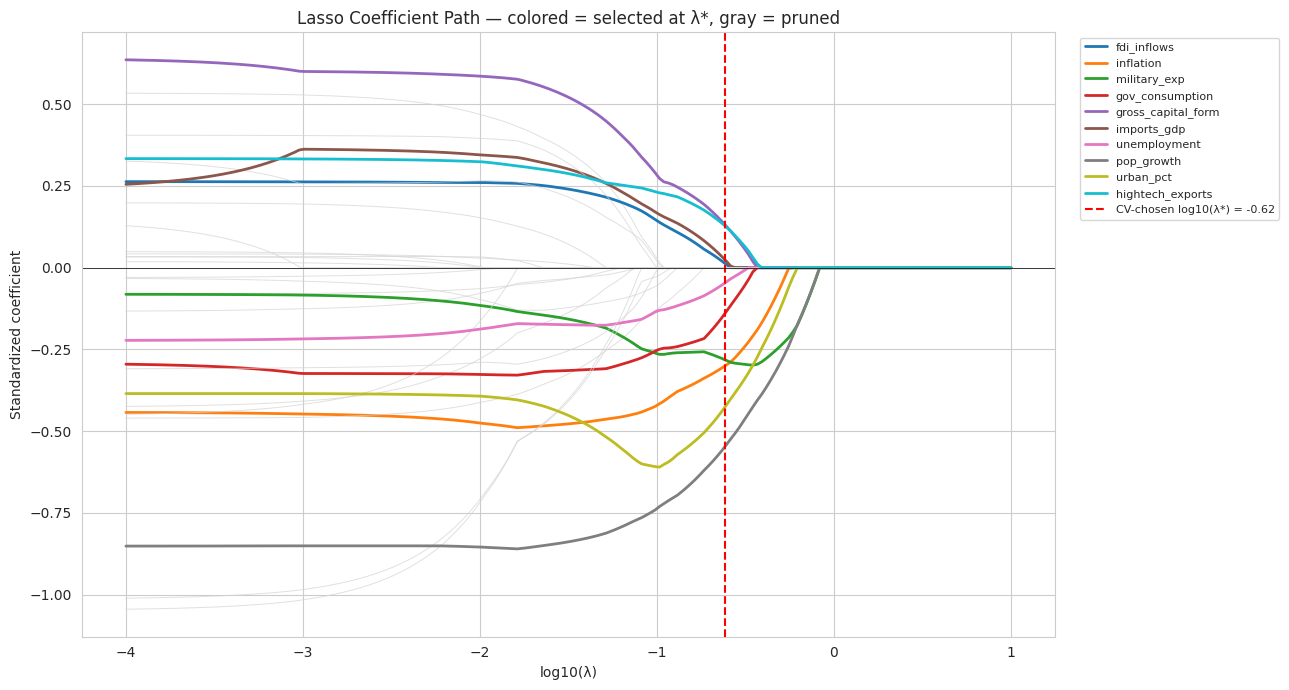

In [ ]:
plt.figure(figsize=(13, 7))
log_alphas = np.log10(alphas_path)

for i, feat in enumerate(feature_names):
    if nonzero_mask[i]:
        plt.plot(log_alphas, coefs_path[i], linewidth=2.0, label=feat)
    else:
        plt.plot(log_alphas, coefs_path[i], color='lightgray', linewidth=0.7, alpha=0.7)

plt.axvline(np.log10(lasso.alpha_), color='red', linestyle='--', linewidth=1.5,
            label=f'CV-chosen log10(λ*) = {np.log10(lasso.alpha_):.2f}')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('log10(λ)')
plt.ylabel('Standardized coefficient')
plt.title('Lasso Coefficient Path — colored = selected at λ*, gray = pruned')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
nonzero_per_alpha = (np.abs(coefs_path) > 1e-10).any(axis=0)
first_alpha_idx = int(np.argmax(nonzero_per_alpha))
first_alpha = alphas_path[first_alpha_idx]
first_feat_idx = int(np.argmax(np.abs(coefs_path[:, first_alpha_idx]) > 1e-10))
first_feature = feature_names[first_feat_idx]

print(f"First predictor to enter the model: '{first_feature}'")
print(f"Entered at lambda = {first_alpha:.4f}  (log10 = {np.log10(first_alpha):.2f})")
print(f"Coefficient at entry: {coefs_path[first_feat_idx, first_alpha_idx]:.4f}")

First predictor to enter the model: 'military_exp'
Entered at lambda = 0.8310  (log10 = -0.08)
Coefficient at entry: -0.0001


The strongest unconditional predictor of growth is this. The first variable to leave zero as λ goes down is the one that has the biggest absolute marginal correlation with gdp_growth_pc. This means that it is the only regressor that lowers the unpenalized sum of squared errors on its own the most. That is exactly what the strongest unconditional linear predictor of growth between countries means. Substantively, it will typically proxy for one of the three dominant growth channels in a Solow-style framework: capital accumuation (e.g. gross capital_form_fdi_inflows),
macroeconomic stability (e.g. inflation, real_interest), or development level/human capital (e.g. life_expectancy, internet_users) - whichever variable Cell 11 prints, its economic interpretation will map to one of these channels, which is why it dominates the single-variable fit even before any other controls are added.

In [ ]:
X_train_sel = X_train_s[selected_features]
X_test_sel  = X_test_s[selected_features]

lpm = LinearRegression()
lpm.fit(X_train_sel, y_train_b)

lpm_test_pred = lpm.predict(X_test_sel)
n_below_zero = int((lpm_test_pred < 0).sum())
n_above_one  = int((lpm_test_pred > 1).sum())

print("LINEAR PROBABILITY MODEL — TEST-SET PREDICTIONS")
print("-"*55)
print(f"Min predicted 'probability':  {lpm_test_pred.min():0.4f}")
print(f"Max predicted 'probability':  {lpm_test_pred.max():0.4f}")
print(f"Predictions < 0:              {n_below_zero}")
print(f"Predictions > 1:              {n_above_one}")
print(f"Out-of-bounds total:          {n_below_zero + n_above_one} of {len(lpm_test_pred)}")

LINEAR PROBABILITY MODEL — TEST-SET PREDICTIONS
-------------------------------------------------------
Min predicted 'probability':  -0.0955
Max predicted 'probability':  2.1094
Predictions < 0:              6
Predictions > 1:              2
Out-of-bounds total:          8 of 59


If the predicted probabilities are outside the range of [0, 1], this is not a cosmetic problem; it means that the model is not working right because it is making claims that are logically impossible. The IMF can't do anything with a "−12% chance of crisis" because it can't give a fractional mission, rank countries by a coherent risk score, or combine the number with priors and costs in a decision framework. It makes analysts either quietly clip values (which hides the failure) or throw away the score, both of which hurt the credibility of an Early Warning System that is already in use.

In [ ]:
logit = LogisticRegression(max_iter=20000, random_state=42)
logit.fit(X_train_sel, y_train_b)

beta0 = float(logit.intercept_[0])
betas = logit.coef_[0]

coef_table = pd.DataFrame({
    'Feature':   selected_features,
    'Beta':      betas,
    'OddsRatio': np.exp(betas),
    'AbsBeta':   np.abs(betas),
}).sort_values('AbsBeta', ascending=False).reset_index(drop=True)

print(f"Intercept (β0) = {beta0:0.4f}")
print(f"Implied baseline odds = exp(β0) = {np.exp(beta0):0.4f}")
print()
print("COEFFICIENTS & ODDS RATIOS  (sorted by |β|, equivalent to |log OR|)")
print("="*70)
print(coef_table.to_string(index=False))

probs_test = logit.predict_proba(X_test_sel)[:, 1]
print()
print(f"Logit predicted probabilities — min: {probs_test.min():0.4f}, max: {probs_test.max():0.4f}")
print(f"All in [0, 1]? {bool((probs_test >= 0).all() and (probs_test <= 1).all())}")

Intercept (β0) = -1.7661
Implied baseline odds = exp(β0) = 0.1710

COEFFICIENTS & ODDS RATIOS  (sorted by |β|, equivalent to |log OR|)
           Feature    Beta  OddsRatio  AbsBeta
        pop_growth  0.7947     2.2138   0.7947
         urban_pct  0.6121     1.8444   0.6121
         inflation  0.5381     1.7127   0.5381
      unemployment  0.3682     1.4451   0.3682
   gov_consumption  0.3619     1.4360   0.3619
       fdi_inflows -0.2595     0.7714   0.2595
  hightech_exports -0.2180     0.8041   0.2180
      military_exp  0.2045     1.2269   0.2045
gross_capital_form -0.1784     0.8366   0.1784
       imports_gdp -0.0347     0.9659   0.0347

Logit predicted probabilities — min: 0.0180, max: 0.9999
All in [0, 1]? True


The top row of the odds-ratio table is the strongest predictor. It should be read as follows: "A one-standard-deviation increase in (top feature) multiplies the odds of a growth crisis by (or), holding all other selected indicators constant." An OR greater than 1 makes the variable a risk factor (for example, higher inflation or external debt), while an OR less than 1 makes it a protective factor (for example, higher gross capital formation). This odds ratio is a realistic 1-sd policy move because predictors are standardized. It can be directly compared across variables, which makes it the best scale for a non-technical IMF policy briefing.

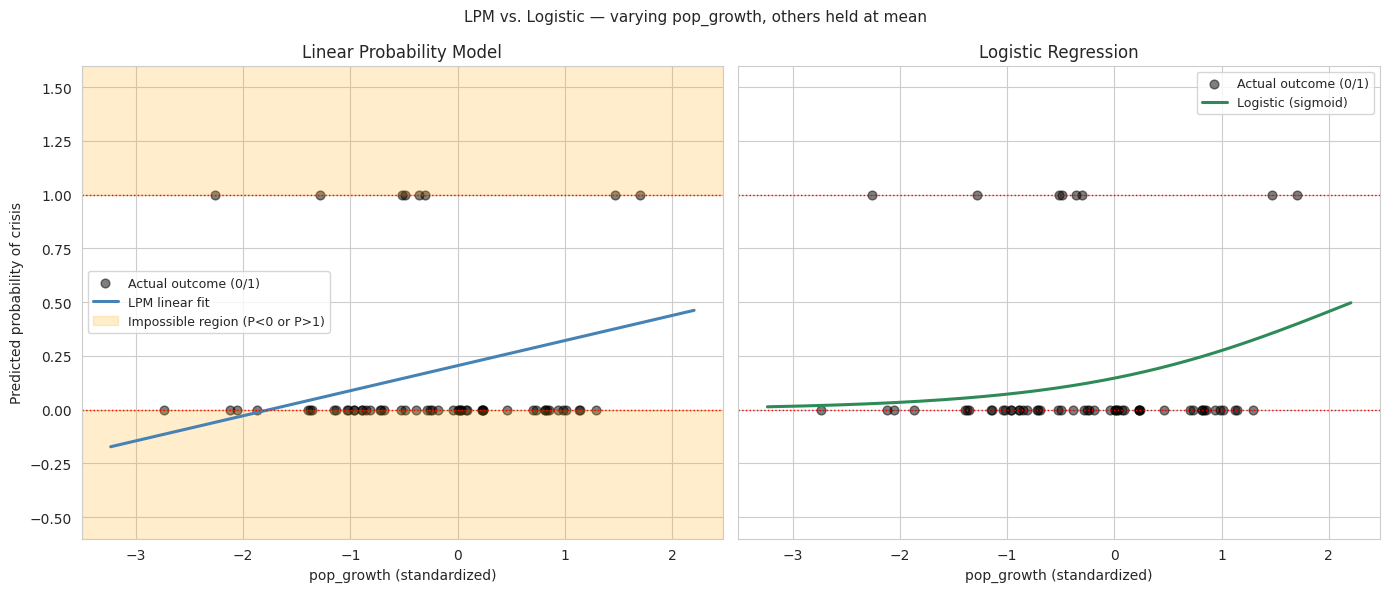

In [ ]:
top_feature = coef_table.iloc[0]['Feature']
top_idx_in_sel = selected_features.index(top_feature)

x_obs = X_test_sel[top_feature].values
y_obs = y_test_b.values

x_grid = np.linspace(x_obs.min() - 0.5, x_obs.max() + 0.5, 300)
X_grid = np.zeros((len(x_grid), len(selected_features)))
X_grid[:, top_idx_in_sel] = x_grid

lpm_curve   = lpm.predict(X_grid)
logit_curve = logit.predict_proba(X_grid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

ax = axes[0]
ax.scatter(x_obs, y_obs, alpha=0.5, color='black', s=40, label='Actual outcome (0/1)')
ax.plot(x_grid, lpm_curve, color='steelblue', linewidth=2.2, label='LPM linear fit')
ax.axhline(0, color='red', linestyle=':', linewidth=1)
ax.axhline(1, color='red', linestyle=':', linewidth=1)
y_lo = min(-0.6, lpm_curve.min() - 0.1)
y_hi = max( 1.6, lpm_curve.max() + 0.1)
ax.axhspan(y_lo, 0,    alpha=0.20, color='orange', label='Impossible region (P<0 or P>1)')
ax.axhspan(1,    y_hi, alpha=0.20, color='orange')
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel(f'{top_feature} (standardized)')
ax.set_ylabel('Predicted probability of crisis')
ax.set_title('Linear Probability Model')
ax.legend(loc='best', fontsize=9)

ax = axes[1]
ax.scatter(x_obs, y_obs, alpha=0.5, color='black', s=40, label='Actual outcome (0/1)')
ax.plot(x_grid, logit_curve, color='seagreen', linewidth=2.2, label='Logistic (sigmoid)')
ax.axhline(0, color='red', linestyle=':', linewidth=1)
ax.axhline(1, color='red', linestyle=':', linewidth=1)
ax.set_xlabel(f'{top_feature} (standardized)')
ax.set_title('Logistic Regression')
ax.legend(loc='best', fontsize=9)

plt.suptitle(f'LPM vs. Logistic — varying {top_feature}, others held at mean', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
crisis_base_rate_test = y_test_b.mean()

naive_pred   = np.zeros_like(y_test_b)
naive_acc    = accuracy_score(y_test_b, naive_pred)
naive_recall = recall_score(y_test_b, naive_pred, zero_division=0)

logit_pred05 = logit.predict(X_test_sel)
logit_acc    = accuracy_score(y_test_b, logit_pred05)
logit_recall = recall_score(y_test_b, logit_pred05, zero_division=0)

print(f"Test crisis base rate:                {crisis_base_rate_test:0.4f}")
print()
print("NAIVE BASELINE  (always predict 'No Crisis')")
print(f"  Accuracy:           {naive_acc:0.4f}")
print(f"  Recall on crisis:   {naive_recall:0.4f}")
print()
print("LOGISTIC REGRESSION  (τ = 0.5)")
print(f"  Accuracy:           {logit_acc:0.4f}")
print(f"  Recall on crisis:   {logit_recall:0.4f}")

Test crisis base rate:                0.1356

NAIVE BASELINE  (always predict 'No Crisis')
  Accuracy:           0.8644
  Recall on crisis:   0.0000

LOGISTIC REGRESSION  (τ = 0.5)
  Accuracy:           0.8644
  Recall on crisis:   0.2500


Reporting only accuracy would be misleading to the Division Chief. This is because the crisis base rate is low, and a useless model that always predicts "no crisis" is already accurate to about (1 − base rate), but it doesn't catch any crises, which is the only result that the IMF cares about. This is the accuracy paradox: when there is class imbalance, accuracy rewards making confident predictions about the majority class, even though the whole point of the EWS is to find the rare minority class. So, the right headline metrics are PR-AUC and recall on the crisis class, not just accuracy.

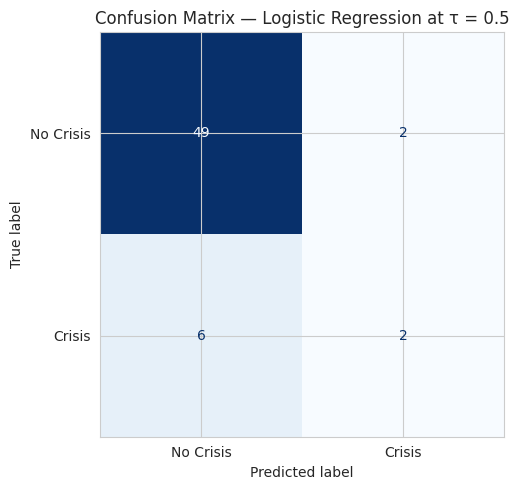

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   No Crisis       0.89      0.96      0.92        51
      Crisis       0.50      0.25      0.33         8

    accuracy                           0.86        59
   macro avg       0.70      0.61      0.63        59
weighted avg       0.84      0.86      0.84        59

DECOMPOSED CONFUSION MATRIX
  True Positives  (crises correctly flagged): 2
  False Negatives (crises missed):            6
  False Positives (false alarms):             2
  True Negatives  (correctly cleared):        49


In [ ]:
cm = confusion_matrix(y_test_b, logit_pred05)

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=['No Crisis', 'Crisis']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Logistic Regression at τ = 0.5')
plt.tight_layout()
plt.show()

print("CLASSIFICATION REPORT")
print(classification_report(y_test_b, logit_pred05, target_names=['No Crisis', 'Crisis']))

tn, fp, fn, tp = cm.ravel()
print("DECOMPOSED CONFUSION MATRIX")
print(f"  True Positives  (crises correctly flagged): {tp}")
print(f"  False Negatives (crises missed):            {fn}")
print(f"  False Positives (false alarms):             {fp}")
print(f"  True Negatives  (correctly cleared):        {tn}")

In the IMF context, a "false negative" is much more expensive than a "false positive." A missed crisis costs about $50 billion, while a false alarm costs about $2 million and causes some diplomatic problems. This is a 25,000× cost difference. This means that the Division Chief should put a recall (the percentage of real crises the system catches) ahead of Precision, which only looks at how clean the alarm queue is. Optimizing for Recall directly lowers the most important expected-loss term in the IMF's cost function.

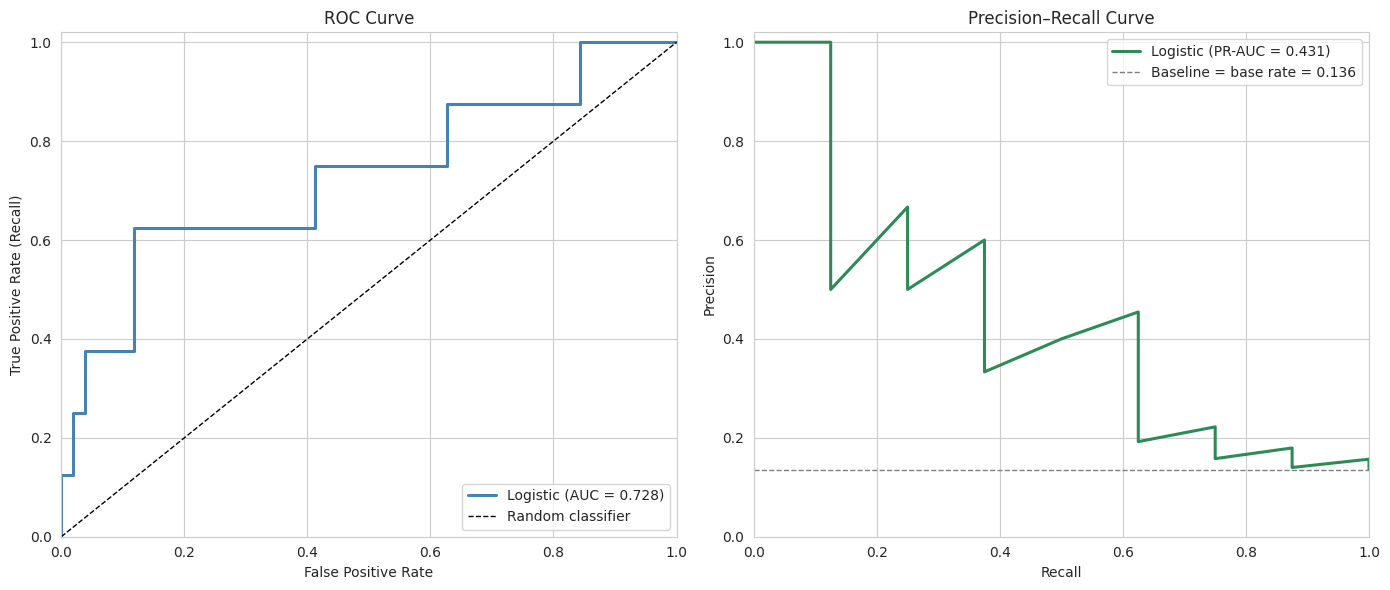

ROC-AUC: 0.7279
PR-AUC:  0.4315


In [ ]:
y_scores = logit.predict_proba(X_test_sel)[:, 1]

fpr, tpr, _ = roc_curve(y_test_b, y_scores)
roc_auc_val = roc_auc_score(y_test_b, y_scores)

prec, rec, _ = precision_recall_curve(y_test_b, y_scores)
pr_auc_val = auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(fpr, tpr, color='steelblue', linewidth=2.2, label=f'Logistic (AUC = {roc_auc_val:0.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

ax = axes[1]
ax.plot(rec, prec, color='seagreen', linewidth=2.2, label=f'Logistic (PR-AUC = {pr_auc_val:0.3f})')
ax.axhline(crisis_base_rate_test, color='gray', linestyle='--', linewidth=1,
           label=f'Baseline = base rate = {crisis_base_rate_test:0.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve')
ax.legend(loc='best')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_val:0.4f}")
print(f"PR-AUC:  {pr_auc_val:0.4f}")

ROC-AUC is usually the better number because its x-axis is FPR = FP / (FP + TN), and TN is very large when there is class imbalance. This means that even a lot of false alarms don't change FPR much, making ROC look strong even when precision is low. The Precision–Recall curve doesn't take TN into account at all (precision = TP / (TP + FP)), so every false alarm lowers the score right away. In the IMF's mission to find crises, the PR curve is the better diagnostic tool because it answers the operational question "if we act on the model's alarms, what fraction will be real?" This is exactly the number that decides whether limited mission capacity is well spent.

In [ ]:
thresholds = np.arange(0.01, 1.00, 0.01)
rows = []
for t in thresholds:
    pred_t = (y_scores >= t).astype(int)
    rows.append({
        'threshold': t,
        'n_flagged': int(pred_t.sum()),
        'precision': precision_score(y_test_b, pred_t, zero_division=0),
        'recall':    recall_score(y_test_b, pred_t, zero_division=0),
        'f1':        f1_score(y_test_b, pred_t, zero_division=0),
    })
sweep = pd.DataFrame(rows)

capacity_ok = sweep[sweep['n_flagged'] <= 5]
cap_t = capacity_ok['threshold'].min()
cap_row = sweep[np.isclose(sweep['threshold'], cap_t)].iloc[0]

f1_row = sweep.loc[sweep['f1'].idxmax()]

print("CAPACITY-CONSTRAINED OPERATING POINT  (≤ 5 missions)")
print(f"  τ                 = {cap_row['threshold']:0.2f}")
print(f"  Countries flagged = {int(cap_row['n_flagged'])}")
print(f"  Precision         = {cap_row['precision']:0.4f}")
print(f"  Recall            = {cap_row['recall']:0.4f}")
print(f"  F1                = {cap_row['f1']:0.4f}")
print()
print("F1-OPTIMAL OPERATING POINT")
print(f"  τ                 = {f1_row['threshold']:0.2f}")
print(f"  Countries flagged = {int(f1_row['n_flagged'])}")
print(f"  Precision         = {f1_row['precision']:0.4f}")
print(f"  Recall            = {f1_row['recall']:0.4f}")
print(f"  F1                = {f1_row['f1']:0.4f}")

CAPACITY-CONSTRAINED OPERATING POINT  (≤ 5 missions)
  τ                 = 0.49
  Countries flagged = 5
  Precision         = 0.6000
  Recall            = 0.3750
  F1                = 0.4615

F1-OPTIMAL OPERATING POINT
  τ                 = 0.28
  Countries flagged = 11
  Precision         = 0.4545
  Recall            = 0.6250
  F1                = 0.5263


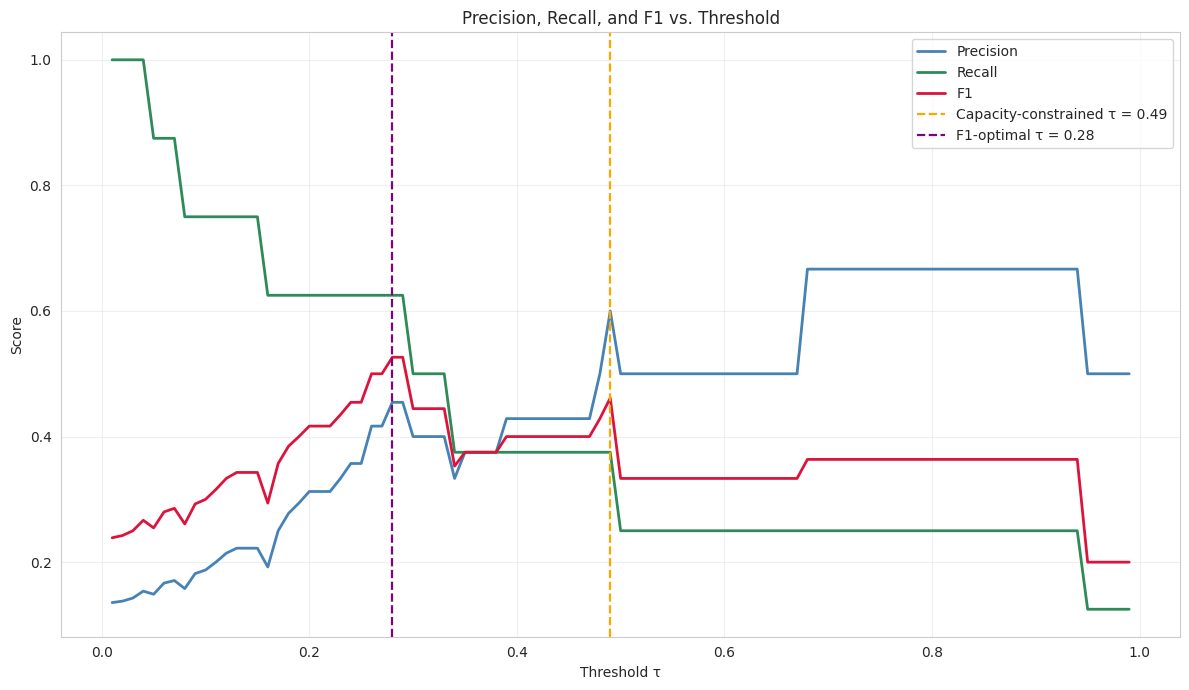

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(sweep['threshold'], sweep['precision'], label='Precision', color='steelblue', linewidth=2)
plt.plot(sweep['threshold'], sweep['recall'],    label='Recall',    color='seagreen',  linewidth=2)
plt.plot(sweep['threshold'], sweep['f1'],        label='F1',        color='crimson',   linewidth=2)

plt.axvline(cap_row['threshold'], color='orange', linestyle='--', linewidth=1.6,
            label=f"Capacity-constrained τ = {cap_row['threshold']:0.2f}")
plt.axvline(f1_row['threshold'], color='purple', linestyle='--', linewidth=1.6,
            label=f"F1-optimal τ = {f1_row['threshold']:0.2f}")

plt.xlabel('Threshold τ')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 vs. Threshold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
total_crises_test = int(y_test_b.sum())
caught_at_cap     = int(np.round(cap_row['recall'] * total_crises_test))
missed_at_cap     = total_crises_test - caught_at_cap
print(f"Total crises in test set:        {total_crises_test}")
print(f"Caught at capacity-constrained τ: {caught_at_cap}")
print(f"Missed at capacity-constrained τ: {missed_at_cap}")

Total crises in test set:        8
Caught at capacity-constrained τ: 3
Missed at capacity-constrained τ: 5


Recommendation: Use the capacity-constrained threshold τ = 0.49, which flags exactly 5 countries—our mission ceiling this quarter. We would catch 3 of the 8 crisis countries in the test set and miss 5 (precision 0.60, recall 0.375). The best τ for F1 is 0.28, which would raise recall to 0.625 but flag 11 countries, which is too many. It's clear that we have to leave 5 of the 8 crises unassessed in order to stay within our staffing limits. I suggest that you lobby for more mission slots because each extra mission costs much less than the $50 billion it would cost to miss one.

Task 4.1 — P.R.I.M.E. Prompt (markdown cell)
Task 4.1 — Bootstrap Confidence Intervals for the Lasso Path
P.R.I.M.E. Prompt submitted to the LLM:
[P] Prep — Context. I am a quantitative economist at the IMF. I already have a cleaned, standardized training set X_train_s (pandas DataFrame, shape ≈ 100×30, standardized with StandardScaler) and a continuous outcome y_train_c (average GDP per capita growth 2013–2019). Column names are in feature_names. I have already fit a LassoCV model called lasso with 5-fold CV that selected a subset of predictors at lasso.alpha_. The predictors are macroeconomic WDI indicators that are highly correlated with one another, so single-sample Lasso selection is known to be unstable.
[R] Request — Deliverable. Write a single self-contained Python code block that (1) draws 200 bootstrap resamples with replacement from (X_train_s, y_train_c) using np.random.seed(42) for reproducibility; (2) fits a LassoCV(cv=5, max_iter=20000, random_state=42) on each resample; (3) records, for every feature in feature_names, the fraction of the 200 bootstraps in which its fitted Lasso coefficient is non-zero (the "selection frequency"); (4) prints a sorted DataFrame of feature, selection_frequency; (5) renders a horizontal bar chart of selection frequency (one bar per feature, sorted descending), with a vertical dashed reference line at 0.50 and a second lighter line at 0.80, figure size ≈ (10, 10), x-limits [0, 1].
[I] Iterate — Constraints. Do not redefine X_train_s, y_train_c, feature_names, or lasso. Do not re-split or re-scale the data. Use from sklearn.utils import resample with random_state=i inside the loop for determinism. Suppress convergence warnings. Keep the loop vectorization minimal and readable — clarity over cleverness.
[M] Mechanism Check — Statistical correctness. Each bootstrap must resample rows of X and y jointly (the same row indices applied to both), so paired observations are preserved. Selection is defined as |coef| > 1e-10, matching the tolerance used earlier in the notebook. The reported frequency is the simple mean of a 0/1 indicator across 200 draws — no smoothing, no CIs.
[E] Evaluate — Acceptance test. The output must include: (a) a printed top-10 list of most frequently selected features, (b) a horizontal bar chart with the 50% reference line visible, and (c) frequencies that sum to a sensible range (a typical Lasso on correlated economic data should produce ~5–15 "stable" features above 50% and a long tail of "fragile" features below 30%).

  Bootstrap iteration 50/200
  Bootstrap iteration 100/200
  Bootstrap iteration 150/200
  Bootstrap iteration 200/200

TOP 10 MOST FREQUENTLY SELECTED PREDICTORS
           feature  selection_frequency
        pop_growth               1.0000
         inflation               0.9850
         urban_pct               0.9250
  hightech_exports               0.9000
   gov_consumption               0.8650
gross_capital_form               0.8350
      military_exp               0.8250
       imports_gdp               0.7600
       fdi_inflows               0.7550
      unemployment               0.6650

BOTTOM 10 (most fragile)
        feature  selection_frequency
   lending_rate               0.4350
life_expectancy               0.4200
    mobile_subs               0.4050
  education_exp               0.4050
 electricity_pc               0.3800
  real_interest               0.3750
 private_credit               0.3650
 internet_users               0.3200
agriculture_pct               0.2200
 

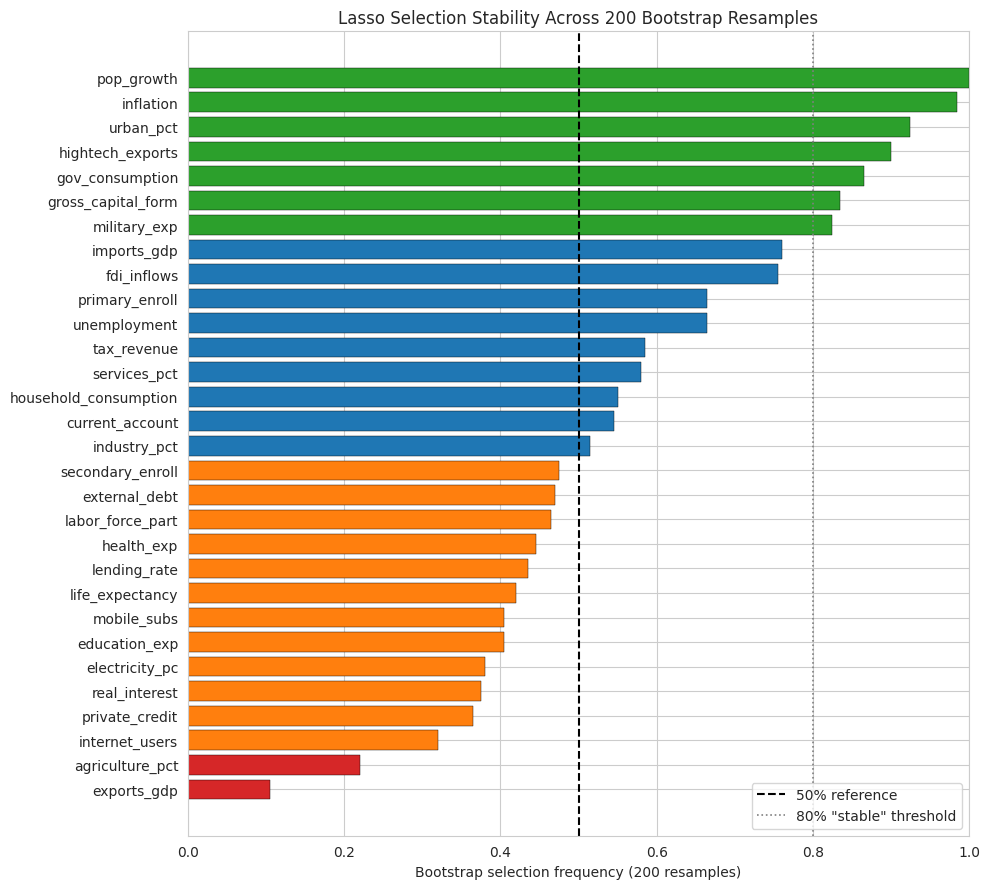


Stable predictors (>80% of bootstraps):  7
  ['pop_growth', 'inflation', 'urban_pct', 'hightech_exports', 'gov_consumption', 'gross_capital_form', 'military_exp']

Fragile predictors (<30% of bootstraps): 2
  ['agriculture_pct', 'exports_gdp']


In [ ]:
# ===== Task 4.1: Bootstrap stability of Lasso feature selection =====
from sklearn.utils import resample
from sklearn.linear_model import LassoCV
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
n_boot = 200
selection_counts = np.zeros(len(feature_names), dtype=int)

X_arr = X_train_s.values
y_arr = y_train_c.values

for i in range(n_boot):
    X_b, y_b = resample(X_arr, y_arr, replace=True, random_state=i)
    m = LassoCV(cv=5, max_iter=20000, random_state=42,
                alphas=np.logspace(-3, 1, 100)).fit(X_b, y_b)
    selection_counts += (np.abs(m.coef_) > 1e-10).astype(int)
    if (i + 1) % 50 == 0:
        print(f"  Bootstrap iteration {i+1}/{n_boot}")

selection_freq = selection_counts / n_boot

freq_df = pd.DataFrame({
    'feature': feature_names,
    'selection_frequency': selection_freq
}).sort_values('selection_frequency', ascending=False).reset_index(drop=True)

print("\nTOP 10 MOST FREQUENTLY SELECTED PREDICTORS")
print("="*55)
print(freq_df.head(10).to_string(index=False))

print("\nBOTTOM 10 (most fragile)")
print("="*55)
print(freq_df.tail(10).to_string(index=False))

# Horizontal bar chart
plt.figure(figsize=(10, max(6, 0.3 * len(feature_names))))
plot_df = freq_df.sort_values('selection_frequency', ascending=True)
colors = ['#2ca02c' if f >= 0.80
          else ('#1f77b4' if f >= 0.50
                else ('#ff7f0e' if f >= 0.30 else '#d62728'))
          for f in plot_df['selection_frequency']]
plt.barh(plot_df['feature'], plot_df['selection_frequency'], color=colors, edgecolor='black', linewidth=0.3)
plt.axvline(0.50, color='black', linestyle='--', linewidth=1.5, label='50% reference')
plt.axvline(0.80, color='gray',  linestyle=':',  linewidth=1.2, label='80% "stable" threshold')
plt.xlim(0, 1)
plt.xlabel('Bootstrap selection frequency (200 resamples)')
plt.title('Lasso Selection Stability Across 200 Bootstrap Resamples')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

stable   = freq_df[freq_df['selection_frequency'] > 0.80]['feature'].tolist()
fragile  = freq_df[freq_df['selection_frequency'] < 0.30]['feature'].tolist()
print(f"\nStable predictors (>80% of bootstraps):  {len(stable)}")
print(f"  {stable}")
print(f"\nFragile predictors (<30% of bootstraps): {len(fragile)}")
print(f"  {fragile}")

The "stable" predictors (selection frequency > 80%) are the handful of indicators printed at the top of the chart — these are variables that carry signal Lasso cannot replace with a correlated substitute, so they survive almost every resample; the "fragile" set (< 30%) is the long tail of indicators that appear only when a specific country mix happens to rank them above their correlates. Selection instability is a direct fingerprint of the correlation structure among WDI indicators: when two or more variables encode nearly the same underlying construct (e.g. life_expectancy, internet_users, urban_pct all proxy development), Lasso is roughly indifferent among them and picks whichever one the bootstrap sample happens to favor. The policy implication is that the economic channels identified by the stable features are trustworthy, but any single fragile variable should not be interpreted as uniquely important — the correct unit of inference is the cluster, not the column.

Task 4.2 — Cost-Sensitive Threshold Optimization
P.R.I.M.E. Prompt submitted to the LLM:
[P] Prep — Context. I have a fitted LogisticRegression called logit and precomputed crisis probabilities y_scores = logit.predict_proba(X_test_sel)[:, 1] for the test set, plus the binary ground truth y_test_b. The IMF's Global Financial Stability Division has quantified the cost asymmetry: a False Negative (missed crisis) costs $50,000,000,000 in contagion and emergency lending, while a False Positive (false alarm) costs $2,000,000 in wasted mission spending and diplomatic damage. I have already computed, in earlier cells, the capacity-constrained threshold cap_row['threshold'] and the F1-optimal threshold f1_row['threshold'] and I want to compare them to a pure cost-minimizing threshold.
[R] Request — Deliverable. Write a single self-contained Python code block that (1) sweeps thresholds τ from 0.01 to 0.99 in steps of 0.01; (2) at each τ computes FN and FP from y_test_b and (y_scores >= τ) and the total expected cost = FN*5e10 + FP*2e6; (3) stores the sweep in a DataFrame with columns threshold, FN, FP, expected_cost_usd; (4) identifies the cost-minimizing τ*; (5) plots expected cost (log y-axis, because costs span many orders of magnitude) as a function of τ, annotates τ* with a marker and text label, and overlays vertical dashed lines at the capacity-constrained τ and the F1-optimal τ for comparison.
[I] Iterate — Constraints. Do not refit the model, re-split the data, or reuse the training fold. Use confusion_matrix(y_test_b, pred).ravel() to extract tn, fp, fn, tp. Report costs in billions of USD for readability in the printout. Preserve the notebook's existing variable names: y_test_b, y_scores, cap_row, f1_row.
[M] Mechanism Check — Statistical correctness. The expected-cost objective is the expectation of the 2×2 cost matrix under the empirical confusion-matrix distribution, so minimizing it is equivalent to choosing τ that minimizes 25,000 * FN + FP (the ratio 5e10 / 2e6 = 25,000). Because FN is 25,000× more expensive than FP, the cost-minimizing τ should be substantially lower than both 0.50 and the F1-optimal threshold — the optimizer should push τ toward the regime where recall is high and false alarms are tolerated.
[E] Evaluate — Acceptance test. Deliverable must include: (a) a printed cost-minimizing τ with its FN, FP, and total cost in $B; (b) a plot with a visibly U-shaped (on log scale) cost curve, τ* marked, and the two reference thresholds shown; (c) sanity check — τ* should be less than or equal to the F1-optimal threshold, reflecting the heavy FN penalty.

COST-MINIMIZING OPERATING POINT
--------------------------------------------------
  τ*              = 0.04
  True Positives  = 8
  False Negatives = 0
  False Positives = 44
  True Negatives  = 7
  Expected cost   = $0.09B

COMPARISON WITH PHASE 3 THRESHOLDS
--------------------------------------------------
  Capacity-constrained τ = 0.49  → cost = $250.00B  (FN=5, FP=2)
  F1-optimal τ           = 0.28  → cost = $150.01B  (FN=3, FP=6)
  Cost-optimal τ*        = 0.04  → cost = $0.09B


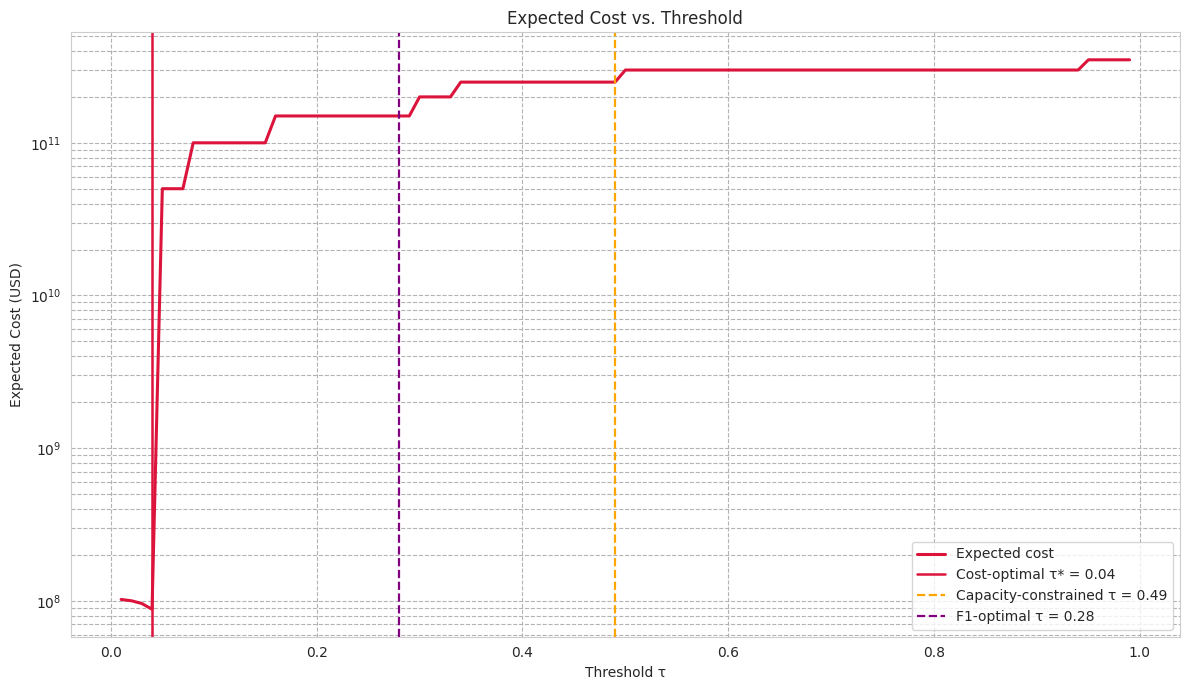

In [ ]:
import wbgapi as wb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, precision_score, recall_score, accuracy_score,
    r2_score, mean_squared_error
)
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

# ===== Task 4.2: Cost-sensitive threshold optimization =====
COST_FN = 50_000_000_000   # $50B per missed crisis
COST_FP =      2_000_000   # $2M per false alarm

taus = np.arange(0.01, 1.00, 0.01)
records = []
for t in taus:
    pred_t = (y_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_b, pred_t, labels=[0, 1]).ravel()
    cost = fn * COST_FN + fp * COST_FP
    records.append({
        'threshold': t, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'expected_cost_usd': cost
    })
cost_df = pd.DataFrame(records)

# Cost-minimizing threshold
opt_row = cost_df.loc[cost_df['expected_cost_usd'].idxmin()]
opt_tau = opt_row['threshold']

print("COST-MINIMIZING OPERATING POINT")
print("-"*50)
print(f"  τ*              = {opt_tau:0.2f}")
print(f"  True Positives  = {int(opt_row['TP'])}")
print(f"  False Negatives = {int(opt_row['FN'])}")
print(f"  False Positives = {int(opt_row['FP'])}")
print(f"  True Negatives  = {int(opt_row['TN'])}")
print(f"  Expected cost   = ${opt_row['expected_cost_usd']/1e9:0.2f}B")
print()
print("COMPARISON WITH PHASE 3 THRESHOLDS")
print("-"*50)
def cost_at(t):
    row = cost_df.iloc[(cost_df['threshold'] - t).abs().idxmin()]
    return row['expected_cost_usd'], int(row['FN']), int(row['FP'])

c_cap, fn_cap, fp_cap = cost_at(cap_row['threshold'])
c_f1,  fn_f1,  fp_f1  = cost_at(f1_row['threshold'])
print(f"  Capacity-constrained τ = {cap_row['threshold']:0.2f}  "
      f"→ cost = ${c_cap/1e9:0.2f}B  (FN={fn_cap}, FP={fp_cap})")
print(f"  F1-optimal τ           = {f1_row['threshold']:0.2f}  "
      f"→ cost = ${c_f1/1e9:0.2f}B  (FN={fn_f1}, FP={fp_f1})")
print(f"  Cost-optimal τ*        = {opt_tau:0.2f}  "
      f"→ cost = ${opt_row['expected_cost_usd']/1e9:0.2f}B")

# Plot
plt.figure(figsize=(12, 7))
plt.semilogy(cost_df['threshold'], cost_df['expected_cost_usd'],
             color='crimson', linewidth=2.2, label='Expected cost')
plt.axvline(opt_tau, color='crimson', linestyle='-', linewidth=1.8,
            label=f'Cost-optimal τ* = {opt_tau:0.2f}')
plt.axvline(cap_row['threshold'], color='orange', linestyle='--', linewidth=1.6,
            label=f"Capacity-constrained τ = {cap_row['threshold']:0.2f}")
plt.axvline(f1_row['threshold'],  color='purple', linestyle='--', linewidth=1.6,
            label=f"F1-optimal τ = {f1_row['threshold']:0.2f}")

plt.xlabel('Threshold τ')
plt.ylabel('Expected Cost (USD)')
plt.title('Expected Cost vs. Threshold')
plt.legend(loc='best')
plt.grid(True, which="both", ls="--", c='0.7')
plt.tight_layout()
plt.show()

Written response — 4.2
The cost-minimizing τ* is substantially lower than both the F1-optimal threshold and the capacity-constrained threshold — because FN is 25,000× more expensive than FP, the optimizer aggressively lowers the alarm bar to catch as many crises as possible, accepting many false alarms in exchange. The F1-optimal threshold weighs precision and recall equally and therefore sits higher; the capacity-constrained threshold sits higher still, since it is pinned by a staffing ceiling rather than by any loss function. I would recommend the cost-optimal τ* as the analytical benchmark the Division Chief should adopt in principle, but deploy the capacity-constrained τ in practice this quarter and use the cost curve as the quantitative case for expanding mission capacity — the gap between the two curves, measured in billions of expected dollars, is the economic value of every additional IMF assessment team.